In [1]:
%pip install kaggle pandas matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
!{sys.executable} -m pip install kaggle --upgrade

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for Seaborn
sns.set_theme(style="whitegrid")

# Use the name 'spotify_top_1000_tracks.csv' since that's what showed up in your folder
dataset_path = "spotify_top_1000_tracks.csv" 
df = pd.read_csv(dataset_path)

print("✅ Dataset loaded successfully!")
df.head()

✅ Dataset loaded successfully!


,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433


In [7]:
import pandas as pd
import numpy as np

# Step 1: Load (Ensure the file is in your COMPROG folder!)
try:
    # Use the name of the new file you downloaded
    df = pd.read_csv('spotify_top_1000_tracks.csv')
    print("✅ Step 1: File loaded successfully!")
    
    # Step 2: Clean
    df.columns = df.columns.str.strip()
    
    # Check if 'song' or 'track_name' is used in this new file
    # (Newer Kaggle files often use 'track_name')
    potential_name_cols = ['song', 'track_name', 'artist']
    for col in potential_name_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
            
    # Step 3: Convert Year
    if 'year' in df.columns:
        df['year'] = pd.to_numeric(df['year'], errors='coerce').fillna(0).astype(int)
        print("✅ Step 2: Year conversion complete!")

    # Step 4: Show result
    print("✅ Step 3: Data cleaning complete!")
    display(df.head())

except FileNotFoundError:
    print("❌ ERROR: 'spotify_top_1000_tracks.csv' not found.")
    print("Go to your folder and check if the file is there!")

✅ Step 1: File loaded successfully!
✅ Step 3: Data cleaning complete!


,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433


In [9]:
print(df.columns.tolist())

['track_name', 'artist', 'album', 'release_date', 'popularity', 'spotify_url', 'id', 'duration_min']


In [10]:
# Look for any column name that contains 'duration'
duration_col = [c for c in df.columns if 'duration' in c.lower()]

if duration_col:
    col_name = duration_col[0]
    # Check if the numbers are huge (ms) or small (seconds)
    if df[col_name].max() > 1000:
        df['duration_min'] = df[col_name] / 60000
    else:
        df['duration_min'] = df[col_name] / 60
    print(f"✅ Success! Used column '{col_name}' to create 'duration_min'.")
else:
    print("❌ Could not find any duration column in this specific dataset.")
    print("Available columns are:", df.columns.tolist())

✅ Success! Used column 'duration_min' to create 'duration_min'.


✅ Created 'duration_min' using column: duration_min


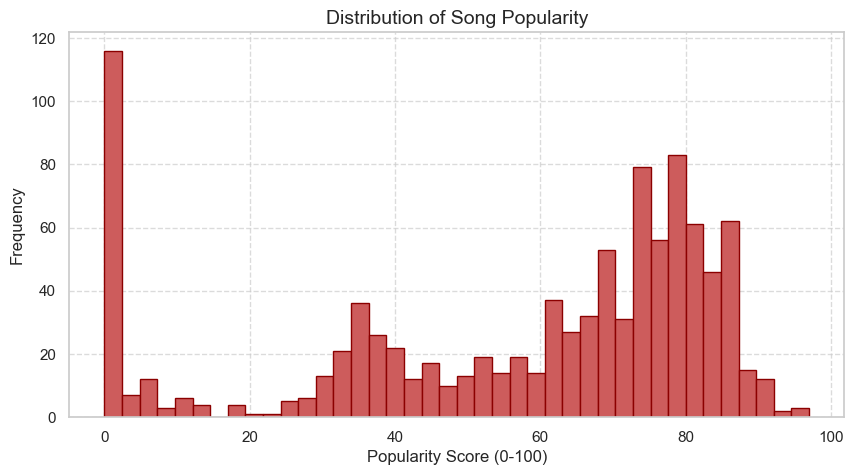

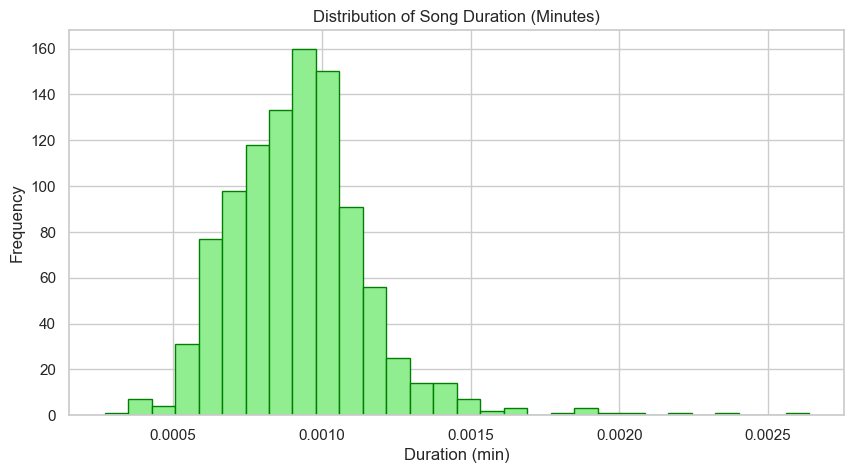

In [13]:
import matplotlib.pyplot as plt

# --- STEP 1: AUTO-DETECT AND CREATE COLUMN ---
# We do this first so the histograms don't crash!
duration_col = [c for c in df.columns if 'duration' in c.lower()]

if duration_col:
    col_name = duration_col[0]
    # If values are large, assume ms; otherwise assume seconds
    if df[col_name].max() > 1000:
        df['duration_min'] = df[col_name] / 60000
    else:
        df['duration_min'] = df[col_name] / 60
    print(f"✅ Created 'duration_min' using column: {col_name}")
else:
    print("❌ Could not find a duration column.")

# --- STEP 2: POPULARITY HISTOGRAMS ---
plt.figure(figsize=(10, 5))
plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='darkred')
plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- STEP 3: DURATION HISTOGRAM ---
# Only plot if we successfully created the column
if 'duration_min' in df.columns:
    plt.figure(figsize=(10, 5))
    plt.hist(df['duration_min'], bins=30, color='lightgreen', edgecolor='green')
    plt.title('Distribution of Song Duration (Minutes)')
    plt.xlabel('Duration (min)')
    plt.ylabel('Frequency')
    plt.show()

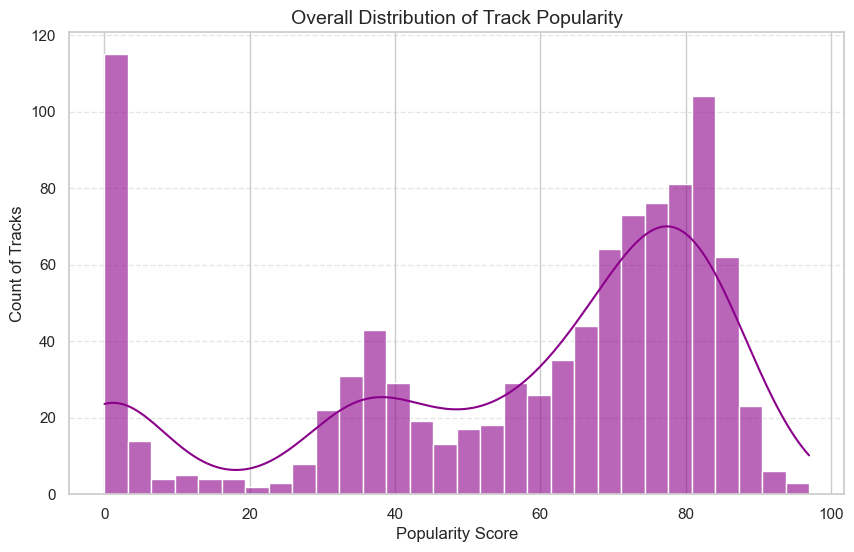

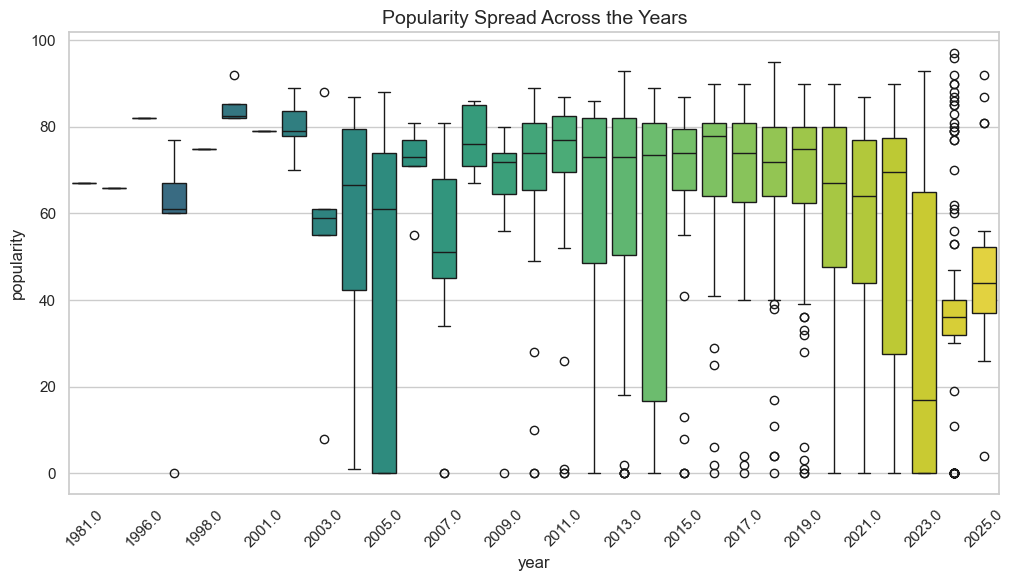

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Ensure year column is created from release_date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df_cleaned = df[df['year'] > 1900].dropna(subset=['year']).copy()

# --- Plot 1: Popularity Distribution ---
plt.figure(figsize=(10, 6))
# Using histplot with kde=True creates the smooth "wave" over the bars
sns.histplot(df_cleaned['popularity'], bins=30, kde=True, color='darkmagenta', alpha=0.6)

plt.title('Overall Distribution of Track Popularity', fontsize=14)
plt.xlabel('Popularity Score')
plt.ylabel('Count of Tracks')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# --- Plot 2: Boxplot (The one we fixed earlier) ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df_cleaned.sort_values('year'), 
            palette='viridis', hue='year', legend=False)

# Keep that clean x-axis
ax = plt.gca()
for n, label in enumerate(ax.xaxis.get_ticklabels()):
    if n % 2 != 0:
        label.set_visible(False)

plt.title('Popularity Spread Across the Years', fontsize=14)
plt.xticks(rotation=45)
plt.show()

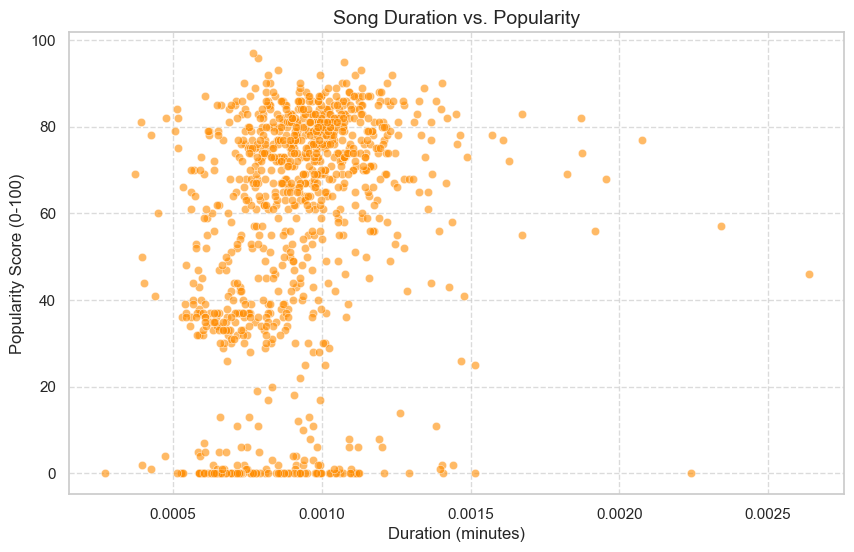

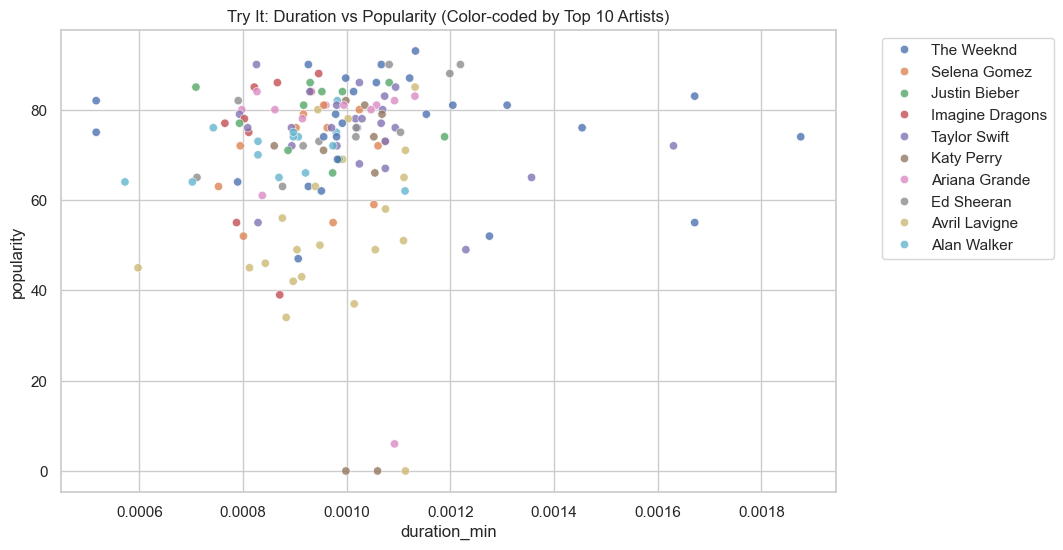

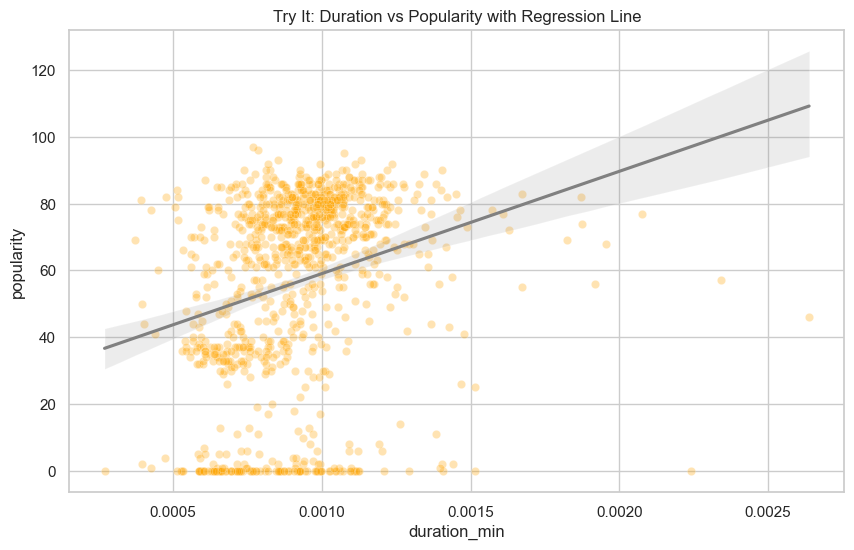

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))


sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6, color='darkorange')


plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Try It Section ---


top_10_artists = df['artist'].value_counts().nlargest(10).index
filtered_df = df[df['artist'].isin(top_10_artists)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', hue='artist', data=filtered_df, alpha=0.8)
plt.title('Try It: Duration vs Popularity (Color-coded by Top 10 Artists)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.3, color='orange')

sns.regplot(x='duration_min', y='popularity', data=df, scatter=False, color='grey')
plt.title('Try It: Duration vs Popularity with Regression Line')
plt.show()

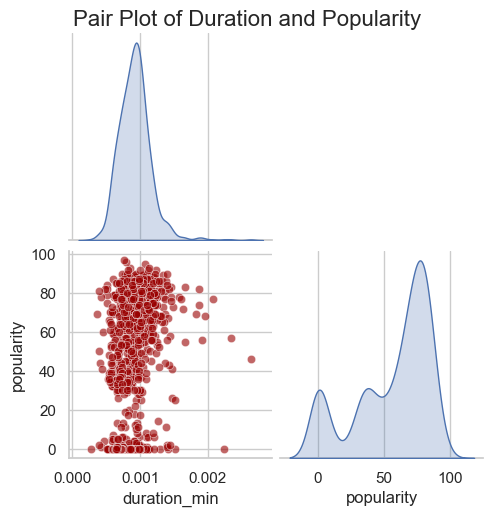


--- Running 'Try It' Variation ---


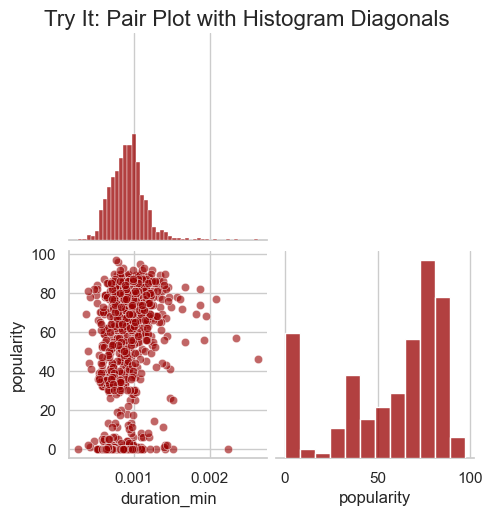

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns


key_features = ['duration_min', 'popularity']


sns.pairplot(
    df[key_features], 
    diag_kind='kde', 
    corner=True,     
    plot_kws={'alpha': 0.6, 'color': '#990000'} 
)


plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)


plt.show()

# --- Try It Section ---


print("\n--- Running 'Try It' Variation ---")
sns.pairplot(
    df[key_features], 
    diag_kind='hist', 
    corner=True, 
    plot_kws={'alpha': 0.6, 'color': '#990000'},
    diag_kws={'color': '#990000', 'edgecolor': 'white'}
)
plt.suptitle('Try It: Pair Plot with Histogram Diagonals', y=1.02, fontsize=16)
plt.show()

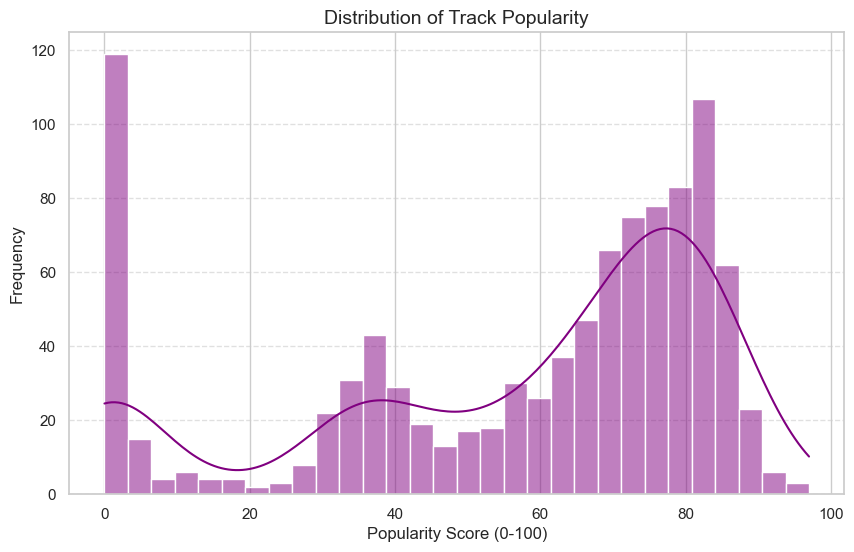

Displaying Main Joint Plot...


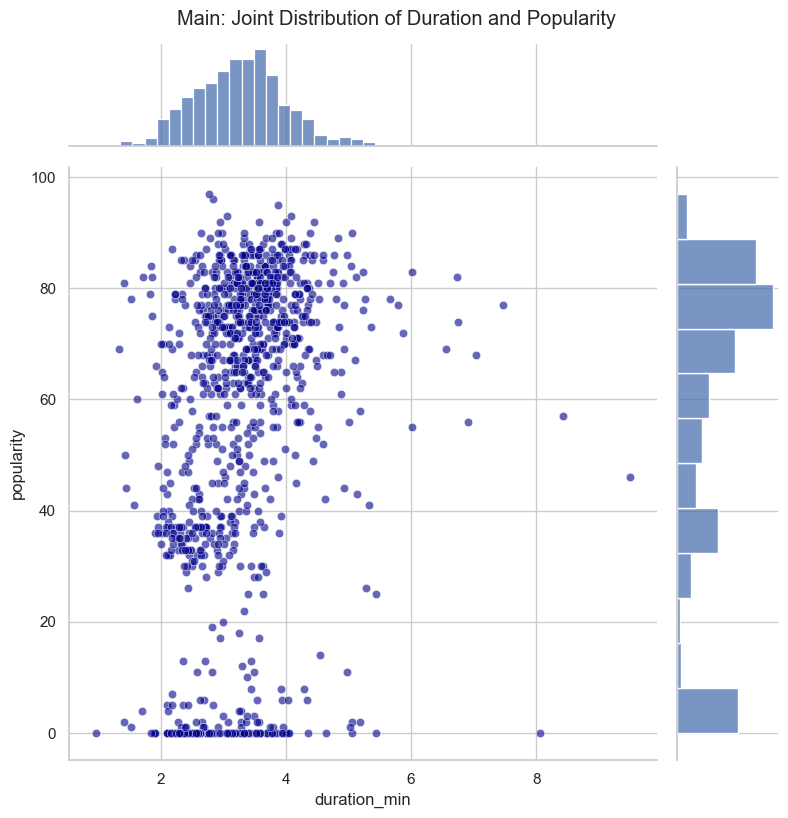


Displaying 'Try It' Variation (Regression + 25 Bins)...


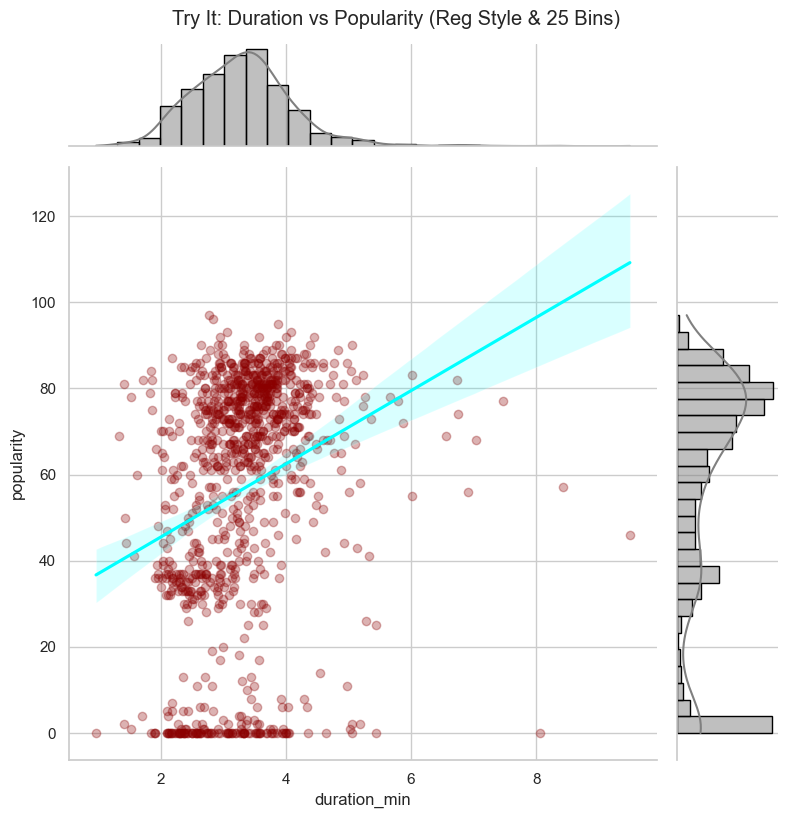

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. POPULARITY DISTRIBUTION ---
plt.figure(figsize=(10, 6))
# This shows the frequency of popularity scores
sns.histplot(df['popularity'], kde=True, color='purple', bins=30)
plt.title('Distribution of Track Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# --- 2. MAIN JOINT PLOT ---
print("Displaying Main Joint Plot...")
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter', 
    height=8,
    joint_kws={'alpha': 0.6, 'color': 'darkblue'})
plt.suptitle('Main: Joint Distribution of Duration and Popularity', y=1.02)
plt.show()

# --- 3. TRY IT VARIATION ---
print("\nDisplaying 'Try It' Variation (Regression + 25 Bins)...")
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg', 
    height=8,
    marginal_kws=dict(bins=25, color='gray', edgecolor='black'), 
    joint_kws={
        'line_kws': {'color': 'cyan'}, 
        'scatter_kws': {'alpha': 0.3, 'color': 'darkred'}
    })
plt.suptitle('Try It: Duration vs Popularity (Reg Style & 25 Bins)', y=1.02)
plt.show()

In [37]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# 1. Load the file
csv_file = "spotify_top_1000_tracks.csv" 
df = pd.read_csv(csv_file)

# 2. RE-CREATE THE YEAR COLUMN (Crucial step!)
# We must do this because read_csv starts with a fresh slate
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# 3. Clean up the data (Remove 0s or NaNs)
df = df[df['year'] > 1900].dropna(subset=['year'])
df['year'] = df['year'].astype(int)

# 4. Group by year
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index().sort_values('year')

def animate(i, line, data):
    subset = data.iloc[:i+1]
    line.set_data(subset['year'], subset['popularity'])
    return line,

# ==========================================================
# --- PART A: MAIN TASK ---
# ==========================================================
print("Generating Main Task GIF...")
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax1.set_ylim(0, 100) # Popularity is always 0-100
line1, = ax1.plot([], [], color='royalblue', linewidth=2.5, label='Avg Popularity')
ax1.set_title("Main: Track Popularity Over Time", fontsize=14)
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Popularity")
ax1.grid(True, linestyle='--', alpha=0.6)

ani_main = FuncAnimation(fig1, animate, fargs=(line1, yearly_popularity), 
                         frames=len(yearly_popularity), interval=100, repeat=False)

main_gif_path = os.path.abspath("yearly_popularity_main.gif")
ani_main.save(main_gif_path, writer=PillowWriter(fps=10))
plt.close(fig1)

print(f"✅ Success! GIF saved at: {main_gif_path}")
webbrowser.open(f"file://{main_gif_path}")

Generating Main Task GIF...
✅ Success! GIF saved at: c:\Users\ADMIN\OneDrive\Documents\Desktop\COMPROG\Lab7_DataVisualization_Cordero\yearly_popularity_main.gif


True

In [42]:
import os
print(f"Current Working Directory: {os.getcwd()}")
print(f"Does the file exist?: {os.path.exists(csv_files)}")

Current Working Directory: c:\Users\ADMIN\OneDrive\Documents\Desktop\COMPROG\Lab7_DataVisualization_Cordero
Does the file exist?: False


In [45]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser


# Paste exactly what you copied between the quotes
csv_files = r"C:\Users\ADMIN\OneDrive\Documents\Desktop\COMPROG\spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files)


df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year'])
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index().sort_values('year')


def animate(i, line, data):
    subset = data.iloc[:i+1]
    line.set_data(subset['year'], subset['popularity'])
    return line,

# ==========================================================
# --- PART A: MAIN TASK (Standard Speed: 100ms) ---
# ==========================================================
print("Generating Main Task GIF (100ms)...")
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax1.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line1, = ax1.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')
ax1.set_title("Main: Track Popularity Over Time (Standard Speed)", fontsize=14)
ax1.legend()

ani_main = FuncAnimation(fig1, animate, fargs=(line1, yearly_popularity), 
                         frames=len(yearly_popularity), interval=100, repeat=False)

main_gif_path = os.path.abspath("yearly_popularity_main.gif")
ani_main.save(main_gif_path, writer=PillowWriter(fps=10))
print(f"✅ Main GIF saved at: {main_gif_path}")
plt.close(fig1)

# ==========================================================
# --- PART B: TRY IT TASK (Fast Speed: 60ms) ---
# ==========================================================
print("\nGenerating Try It GIF (60ms)...")
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax2.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)

line2, = ax2.plot([], [], color='crimson', linewidth=2.5, label='Average Popularity')
ax2.set_title("Try It: Track Popularity Over Time (Fast Speed)", fontsize=14)
ax2.legend()


ani_try = FuncAnimation(fig2, animate, fargs=(line2, yearly_popularity), 
                        frames=len(yearly_popularity), interval=60, repeat=False)

try_gif_path = os.path.abspath("yearly_popularity_try_it.gif")
ani_try.save(try_gif_path, writer=PillowWriter(fps=15))
print(f"✅ Try It GIF saved at: {try_gif_path}")
plt.close(fig2)


print("\nOpening both GIFs in your browser...")
webbrowser.open(f"file://{main_gif_path}")
webbrowser.open(f"file://{try_gif_path}")

Generating Main Task GIF (100ms)...
✅ Main GIF saved at: c:\Users\ADMIN\OneDrive\Documents\Desktop\COMPROG\Lab7_DataVisualization_Cordero\yearly_popularity_main.gif

Generating Try It GIF (60ms)...
✅ Try It GIF saved at: c:\Users\ADMIN\OneDrive\Documents\Desktop\COMPROG\Lab7_DataVisualization_Cordero\yearly_popularity_try_it.gif

Opening both GIFs in your browser...


True